### Week 3 Mini-Assignment

To better finish this assignment, I have packed all my features form last assignment as functions into a new python script

In [1]:
from src.heart_disease import (
    load_data,
    split_age_groups,
    count_chest_pain_types,
    train_model,
)

Here I already import those features into this notebook, I just run these functions to make sure my import success.
 ### 1. Load data 

In [2]:
df = load_data("data/cleanned-selected-columns.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4


### 2. Basic Data Inspection

In [3]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    str    
 2   cp        918 non-null    str    
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    bool   
 6   restecg   918 non-null    str    
 7   thalch    918 non-null    float64
 8   exang     918 non-null    bool   
 9   oldpeak   918 non-null    float64
dtypes: bool(2), float64(4), int64(1), str(3)
memory usage: 82.8 KB


np.int64(0)

In [4]:
# Inspect missing values, duplicates, and zero cholesterol values.
print("Missing values by column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

zero_chol_count = df["chol"].eq(0).sum()
zero_chol_percent = df["chol"].eq(0).mean() * 100

print(f"\nRows with zero cholesterol: {zero_chol_count}")
print(f"Percentage with zero cholesterol: {zero_chol_percent:.2f}%")

Missing values by column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
dtype: int64

Duplicate rows: 0

Rows with zero cholesterol: 172
Percentage with zero cholesterol: 18.74%


In [5]:
# Compare cholesterol summaries with and without zero values.
comparison_df = df.copy()
comparison_df["age_group"] = comparison_df["age"].apply(
    lambda age: "Younger (<54)" if age < 54 else "Older (>=54)"
)

chol_summary = comparison_df.groupby("age_group").agg(
    total_patients=("chol", "size"),
    zero_chol_count=("chol", lambda values: values.eq(0).sum()),
    mean_with_zeros=("chol", "mean"),
    mean_without_zeros=("chol", lambda values: values[values != 0].mean()),
    median_without_zeros=("chol", lambda values: values[values != 0].median()),
)

chol_summary["zero_chol_percent"] = (
    chol_summary["zero_chol_count"] / chol_summary["total_patients"] * 100
)

chol_summary = chol_summary.reindex(["Younger (<54)", "Older (>=54)"])
chol_summary.round(2)

,total_patients,zero_chol_count,mean_with_zeros,mean_without_zeros,median_without_zeros,zero_chol_percent
age_group,,,,,,
Younger (<54),420,59,207.00,240.84,231.0,14.05
Older (>=54),498,113,193.84,250.73,242.0,22.69


### Sensitivity Analysis: Zero Cholesterol Values

The dataset contains no explicit missing values or duplicate rows. However, 172 of 918 records (18.74%) have a cholesterol value of zero.

Zero values occur more frequently in the older group (22.69%) than in the younger group (14.05%). Including zeros, mean cholesterol is higher in the younger group (207.00 versus 193.84). Excluding zeros reverses this comparison: the older group has a higher mean (250.73 versus 240.84) and median (242 versus 231).

This reversal shows that the original age-group comparison is sensitive to how zero values are handled. The meaning of these zeros has not been confirmed, so excluding them is presented as a sensitivity analysis rather than a definitive cleaning rule. The original data remain unchanged, and the nonzero subset may not represent all patients.

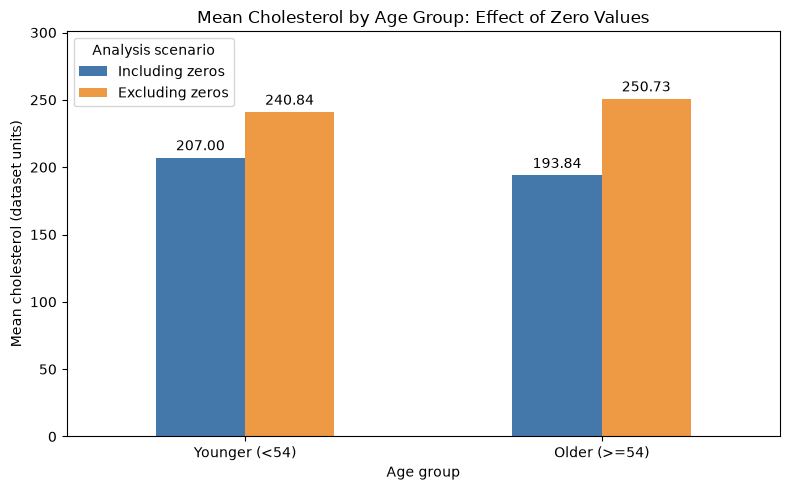

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path

plot_data = chol_summary[["mean_with_zeros", "mean_without_zeros"]].rename(
    columns={
        "mean_with_zeros": "Including zeros",
        "mean_without_zeros": "Excluding zeros",
    }
)

ax = plot_data.plot.bar(
    figsize=(8, 5),
    color=["#4477AA", "#EE9944"],
    rot=0,
)

ax.set_title("Mean Cholesterol by Age Group: Effect of Zero Values")
ax.set_xlabel("Age group")
ax.set_ylabel("Mean cholesterol (dataset units)")
ax.set_ylim(0, plot_data.max().max() * 1.2)
ax.legend(title="Analysis scenario")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()

output_dir = Path("docs/images")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(
    output_dir / "cholesterol-sensitivity.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [7]:
# Check outliers among nonzero cholesterol values.
nonzero_chol = df.loc[df["chol"] != 0, "chol"]

q1 = nonzero_chol.quantile(0.25)
q3 = nonzero_chol.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = nonzero_chol[(nonzero_chol < lower_bound) | (nonzero_chol > upper_bound)]

print(f"Nonzero cholesterol records: {len(nonzero_chol)}")
print(f"IQR lower bound: {lower_bound:.2f}")
print(f"IQR upper bound: {upper_bound:.2f}")
print(f"Flagged outlier records: {len(outliers)}")
print(f"Minimum nonzero cholesterol: {nonzero_chol.min():.2f}")
print(f"Maximum nonzero cholesterol: {nonzero_chol.max():.2f}")

Nonzero cholesterol records: 746
IQR lower bound: 115.00
IQR upper bound: 371.00
Flagged outlier records: 23
Minimum nonzero cholesterol: 85.00
Maximum nonzero cholesterol: 603.00


### Outlier Assessment

Among the 746 records with nonzero cholesterol, 23 (3.08%) fall outside the 1.5 × IQR bounds of 115–371. Nonzero cholesterol values range from 85 to 603.

These records were flagged but retained because the IQR rule alone does not establish that a value is incorrect. No rows were deleted or values capped. The sensitivity analysis excludes only zero cholesterol values in its comparison scenario; nonzero outliers remain included.

Both means and medians were examined. After excluding zeros, the older group has a higher mean and median than the younger group, so the direction of the comparison is consistent across these two summary measures.

### 3. Age Group Analysis

In [8]:
younger_patients, older_patients = split_age_groups(df)

print("Younger patients:", len(younger_patients))
print("Older patients:", len(older_patients))

Younger patients: 420
Older patients: 498


### 4. Chest Pain Type Analysis

In [9]:
younger_cp = count_chest_pain_types(younger_patients)
older_cp = count_chest_pain_types(older_patients)

print("Younger group:")
print(younger_cp)

print("\nOlder group:")
print(older_cp)

Younger group:
cp
asymptomatic      198
non-anginal       102
typical angina    120
dtype: int64

Older group:
cp
asymptomatic      298
non-anginal       101
typical angina     99
dtype: int64


### 5. Model Training and Evaluation

In [10]:
model, predictions, y_test, mse = train_model(df)

print("Mean Squared Error:", mse)

Mean Squared Error: 566.3627749534484


### 6. Testing and Reproducibility

The core workflow is implemented in `src/heart_disease.py`.

Automated tests are stored in the `test/` directory and can be run with:

`pytest -v`

GitHub Actions automatically runs the test suite when changes are pushed to
the main branch.